Brain Tumor Classification Using Pretrained Models with Attention Mechanisms

This project focuses on classifying brain tumors from MRI images using transfer learning and deep learning techniques. The objective is to accurately classify brain MRI scans into four categories Glioma,Meningioma, Pituitary Tumor,No Tumor

To identify the most effective architecture, I evaluated several state-of-the-art pre-trained Convolutional Neural Network (CNN) models, including ,VGG16,VGG19,MobileNet,Xception
InceptionV3.

Each model was fine-tuned using transfer learning and further enhanced with modern deep learning techniques such as Multi-Head Attention, Gaussian Noise Regularization,Batch Normalization, Dropout.
These enhancements were incorporated to improve feature extraction, reduce overfitting, and increase the robustness of the models.

Finally, the performance of each model is evaluated and compared using key classification metrics, including accuracy, precision, recall, F1-score, and confusion matrices, providing a comprehensive comparison of their effectiveness for brain tumor classification.

In [1]:
import os
import pandas as pd
import tensorflow as tf
from google.colab import drive
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.inception_v3 import preprocess_input

from tensorflow.keras.layers import BatchNormalization, GaussianNoise, Input, MultiHeadAttention, Reshape
from tensorflow.keras.optimizers import Adam

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from tensorflow.keras.optimizers import Adam


from sklearn.metrics import classification_report, confusion_matrix
import numpy as np




In [9]:
#Mount kaggle input
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/shijigovindan
/kaggle/input/datasets/shijigovindan/brain-tumor-image-files
/kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1
/kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1/Test
/kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1/Test/pituitary
/kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1/Test/notumor
/kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1/Test/meningioma
/kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1/Test/glioma
/kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1/Train
/kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1/Train/pituitary
/kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1/Train/notumor
/kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1/Train/meningioma
/kaggle/inp

In [10]:
#Get the image path and the labels

image_path = []
labels = []

train_data_path = "/kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1/Train"
test_data_path = "/kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1/Test"

categories = os.listdir(train_data_path)
print(categories)

['pituitary', 'notumor', 'meningioma', 'glioma']


In [11]:
for category in categories:
    # Construct the full path to the current category folder
    category_path = os.path.join(train_data_path, category)

    print(f"Processing category: {category}")

    # Get all image file names in the current category
    file_names = os.listdir(category_path)
    print(f"  Found {len(file_names)} files in {category_path}")

    for file_name in file_names:
        # Construct the full path to the image file
        full_image_path = os.path.join(category_path, file_name)
        image_path.append(full_image_path)
        labels.append(category) # The category name is the label

# Display the first few image paths and labels to verify
print(f"Total images found: {len(image_path)}")
print(f"First 5 image paths: {image_path[:5]}")
print(f"First 5 label: {labels[:5]}")

Processing category: pituitary
  Found 5891 files in /kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1/Train/pituitary
Processing category: notumor
  Found 6380 files in /kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1/Train/notumor
Processing category: meningioma
  Found 5556 files in /kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1/Train/meningioma
Processing category: glioma
  Found 5304 files in /kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1/Train/glioma
Total images found: 23131
First 5 image paths: ['/kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1/Train/pituitary/0664.jpg', '/kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1/Train/pituitary/1269.jpg', '/kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1/Train/pituitary/3863.jpg', '/kaggle/input/datasets/shijigovindan/brain-tumor-image-files/BrainTumor_1/Train/p

In [12]:
# Create a DataFrame
df = pd.DataFrame({"image_path": image_path, "labels": labels})


In [13]:
df.head(10)

,image_path,labels
0,/kaggle/input/datasets/shijigovindan/brain-tum...,pituitary
1,/kaggle/input/datasets/shijigovindan/brain-tum...,pituitary
2,/kaggle/input/datasets/shijigovindan/brain-tum...,pituitary
3,/kaggle/input/datasets/shijigovindan/brain-tum...,pituitary
4,/kaggle/input/datasets/shijigovindan/brain-tum...,pituitary
5,/kaggle/input/datasets/shijigovindan/brain-tum...,pituitary
6,/kaggle/input/datasets/shijigovindan/brain-tum...,pituitary
7,/kaggle/input/datasets/shijigovindan/brain-tum...,pituitary
8,/kaggle/input/datasets/shijigovindan/brain-tum...,pituitary
9,/kaggle/input/datasets/shijigovindan/brain-tum...,pituitary


In [14]:
df.tail(10)

,image_path,labels
23121,/kaggle/input/datasets/shijigovindan/brain-tum...,glioma
23122,/kaggle/input/datasets/shijigovindan/brain-tum...,glioma
23123,/kaggle/input/datasets/shijigovindan/brain-tum...,glioma
23124,/kaggle/input/datasets/shijigovindan/brain-tum...,glioma
23125,/kaggle/input/datasets/shijigovindan/brain-tum...,glioma
23126,/kaggle/input/datasets/shijigovindan/brain-tum...,glioma
23127,/kaggle/input/datasets/shijigovindan/brain-tum...,glioma
23128,/kaggle/input/datasets/shijigovindan/brain-tum...,glioma
23129,/kaggle/input/datasets/shijigovindan/brain-tum...,glioma
23130,/kaggle/input/datasets/shijigovindan/brain-tum...,glioma


In [15]:
df.shape

(23131, 2)

In [16]:
df.columns

Index(['image_path', 'labels'], dtype='object')

In [17]:
df['labels'].unique()

array(['pituitary', 'notumor', 'meningioma', 'glioma'], dtype=object)

In [18]:
df['labels'].value_counts()

labels
notumor       6380
pituitary     5891
meningioma    5556
glioma        5304
Name: count, dtype: int64

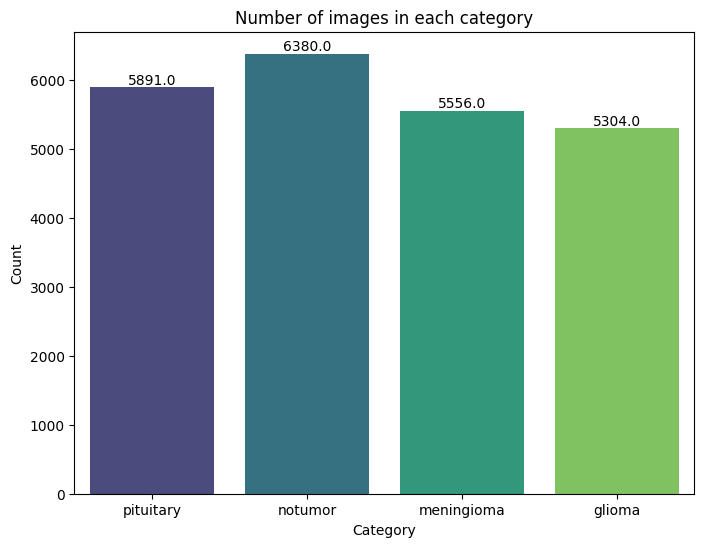

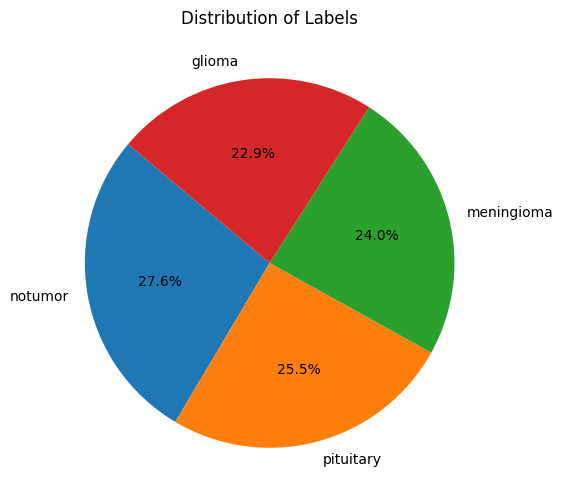

In [19]:
#Plot the graph

plt.figure(figsize=(8,6))
ax = sns.countplot(data=df, x="labels", hue="labels", palette="viridis", legend=False)
plt.title('Number of images in each category')
plt.xlabel('Category')
plt.ylabel('Count')

# Add the total number of images on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

#Plot the pie chart
label_counts = df['labels'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Labels')
plt.show()

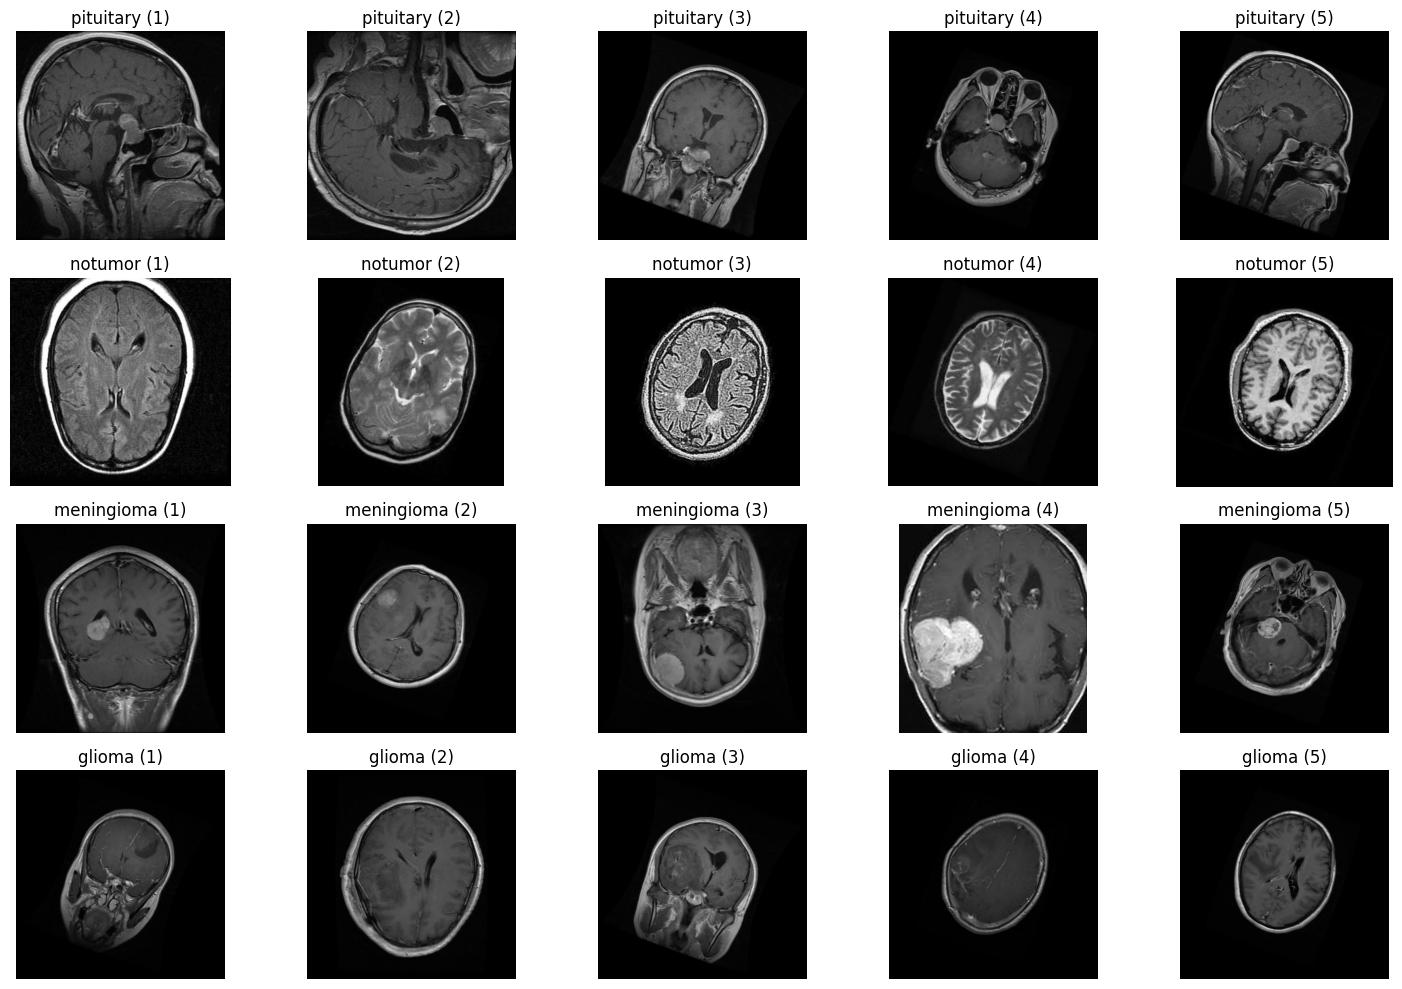

In [20]:
#Display 5 images in each category
import cv2
import random

# Get unique labels
unique_labels = df['labels'].unique()

# Set up the figure for displaying images
plt.figure(figsize=(15, 10))

# Iterate through each label
for i, label in enumerate(unique_labels):
    # Filter DataFrame for the current label
    label_df = df[df['labels'] == label]

    # Select 5 random image paths for the current label
    sample_images = random.sample(list(label_df['image_path']), min(5, len(label_df)))

    # Display the images
    for j, img_path in enumerate(sample_images):
        ax = plt.subplot(len(unique_labels), 5, i * 5 + j + 1)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # OpenCV reads BGR, Matplotlib expects RGB
        plt.imshow(img)
        plt.title(f'{label} ({j+1})')
        plt.axis('off')

plt.tight_layout()
plt.show()

In [21]:
#Apply Label encoding for category

le = LabelEncoder()
df['category_encoded'] = le.fit_transform(df['labels'])
print(df['category_encoded'])

0        3
1        3
2        3
3        3
4        3
        ..
23126    0
23127    0
23128    0
23129    0
23130    0
Name: category_encoded, Length: 23131, dtype: int64


In [22]:
df = df[['image_path','category_encoded']]

In [24]:
#Apply random over sampling

from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(df[['image_path']], df['category_encoded'])



In [25]:
#Data frame after resampling
df_resampled = pd.DataFrame({'image_path': X_resampled.iloc[:, 0], 'category_encoded': y_resampled})

In [26]:
#Class distribution after resampling
print('Class distribution after resampling')
print(df_resampled['category_encoded'].value_counts())


Class distribution after resampling
category_encoded
3    6380
2    6380
1    6380
0    6380
Name: count, dtype: int64


In [27]:
df_resampled

,image_path,category_encoded
0,/kaggle/input/datasets/shijigovindan/brain-tum...,3
1,/kaggle/input/datasets/shijigovindan/brain-tum...,3
2,/kaggle/input/datasets/shijigovindan/brain-tum...,3
3,/kaggle/input/datasets/shijigovindan/brain-tum...,3
4,/kaggle/input/datasets/shijigovindan/brain-tum...,3
...,...,...
25515,/kaggle/input/datasets/shijigovindan/brain-tum...,3
25516,/kaggle/input/datasets/shijigovindan/brain-tum...,3
25517,/kaggle/input/datasets/shijigovindan/brain-tum...,3
25518,/kaggle/input/datasets/shijigovindan/brain-tum...,3


In [28]:
#covert encoded label to string type

df_resampled['category_encoded'] = df_resampled['category_encoded'].astype(str)

In [29]:
#Split the resampled data to 80% test and 20% train

train_df_new, test_temp = train_test_split(df_resampled,
                                     train_size = 0.8,
                                     shuffle = True,
                                     random_state = 42,
                                     stratify = df_resampled['category_encoded'])

In [30]:
#Further split the 20% test to 10% test and 10% validation

test_df_new, val_df = train_test_split(test_temp,
                                   test_size = 0.5,
                                   shuffle = True,
                                   random_state = 42,
                                   stratify = test_temp['category_encoded'])

In [31]:
#Image augmentation using ImageDataGenerator

batch_size = 16
image_size = (224, 224)
channels = 3
image_shape = (image_size[0], image_size[1], channels)

#Instandiate ImageDataGenerators for train and test with scaling

# tr_gen = ImageDataGenerator(rescale = 1./255)
# ts_gen = ImageDataGenerator(rescale = 1./255)

tr_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
ts_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

#Flow from dataframe

train_datagen = tr_gen.flow_from_dataframe(train_df_new,
                                            x_col = 'image_path',
                                            y_col = 'category_encoded',
                                            target_size = image_size,
                                            batch_size = batch_size,
                                            class_mode = 'sparse',
                                            color_mode = 'rgb',
                                            shuffle = True)

test_datagen = ts_gen.flow_from_dataframe(test_df_new,
                                           x_col = 'image_path',
                                           y_col = 'category_encoded',
                                           target_size = image_size,
                                           batch_size = batch_size,
                                           class_mode = 'sparse',
                                           color_mode = 'rgb',
                                           shuffle = False)

val_datagen = ts_gen.flow_from_dataframe(val_df,
                                         x_col = 'image_path',
                                         y_col = 'category_encoded',
                                         target_size = image_size,
                                         batch_size = batch_size,
                                         class_mode = 'sparse',
                                         color_mode = 'rgb',
                                         shuffle = False)




Found 20416 validated image filenames belonging to 4 classes.
Found 2552 validated image filenames belonging to 4 classes.
Found 2552 validated image filenames belonging to 4 classes.


In [32]:
#Check GPU or CPU

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    print("Using GPU")
else:
    print("Using CPU")



Using GPU


In [33]:
#Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [35]:
#Define a function to create VGG16 based model with added attention and custom latyers

def create_vgg16_model(input_shape):

    # Define the input shape for the model
    inputs = tf.keras.Input(shape=input_shape)

    # Load the VGG16 base model with pre-trained weights (ImageNet)
    # Exclude the top layer (include_top=False) to add custom layers

    base_model = VGG16(weights='imagenet', include_top=False, input_tensor=inputs)

    #Freeze all layers in the base model to keep the weight from pre trained model during training

    for layer in base_model.layers:
        layer.trainable = False

    #Extract the output of the base model

    x = base_model.output

    #Define dimensions for reshaping

    height, width, channels = 7, 7, 512 #output dimensions from VGG16

    #Reshape output for multihead attention layer\

    x = tf.keras.layers.Reshape((height * width, channels))(x)

    #Apply multi head attendtion layer to capture feature interactions

    attention_output = tf.keras.layers.MultiHeadAttention(num_heads=8, key_dim=channels)(x, x)

    #Reshape back to spatial dimention

    attention_output = tf.keras.layers.Reshape((height, width, channels))(attention_output)

     # Add Gaussian Noise to introduce slight randomness and enhance generalization

    x = tf.keras.layers.GaussianNoise(0.25)(attention_output)

    #Global average pooling to reduce spacial dimension and keep essential features

    x = GlobalAveragePooling2D()(x)

    #Fully connected layer with RELU activation

    x = Dense(512 , activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)  # Normalize activations to improve stability
    x = tf.keras.layers.GaussianNoise(0.25)(x)   # Add Gaussian noise again for regularization
    x = Dropout(0.25)(x)         # Dropout to prevent overfitting

    #Output layer with softmax activation for multi class classifcation

    outputs = Dense(4, activation='softmax')(x)

    #Create the model

    model = Model(inputs=inputs, outputs=outputs)

    return model

In [36]:
#Set input shape for the model

input_shape = (224, 224, 3)

# Instantiate the model using the create_vgg16_model function

cnn_model = create_vgg16_model(input_shape)

I0000 00:00:1786389798.224989      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786389798.227835      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [37]:

#compile the model with adam optimizer and set up loss and evaluation metrics

cnn_model.compile(optimizer=Adam(learning_rate=0.0001),  # Adam optimizer with specified learning rate
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



In [38]:
#Train the CNN model and store the training history

history = cnn_model.fit(train_datagen,
                        epochs=20,
                        validation_data=val_datagen,
                        callbacks=[early_stopping],
                        verbose=1)



Epoch 1/20
   1/1276 ━━━━━━━━━━━━━━━━━━━━ 5:42:32 16s/step - accuracy: 0.1875 - loss: 1.5927

I0000 00:00:1786389832.058426     117 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1276/1276 ━━━━━━━━━━━━━━━━━━━━ 181s 129ms/step - accuracy: 0.8429 - loss: 0.4364 - val_accuracy: 0.8691 - val_loss: 0.4110
Epoch 2/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 162s 127ms/step - accuracy: 0.9060 - loss: 0.2662 - val_accuracy: 0.7504 - val_loss: 0.8059
Epoch 3/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 162s 127ms/step - accuracy: 0.9265 - loss: 0.2029 - val_accuracy: 0.7684 - val_loss: 0.6664
Epoch 4/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 162s 127ms/step - accuracy: 0.9420 - loss: 0.1669 - val_accuracy: 0.9212 - val_loss: 0.2280
Epoch 5/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 162s 127ms/step - accuracy: 0.9511 - loss: 0.1402 - val_accuracy: 0.9412 - val_loss: 0.1857
Epoch 6/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 162s 127ms/step - accuracy: 0.9613 - loss: 0.1117 - val_accuracy: 0.8672 - val_loss: 0.4277
Epoch 7/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 162s 127ms/step - accuracy: 0.9634 - loss: 0.1016 - val_accuracy: 0.9334 - val_loss: 0.2298
Epoch 8/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 162s 127ms/step - accuracy: 0.9

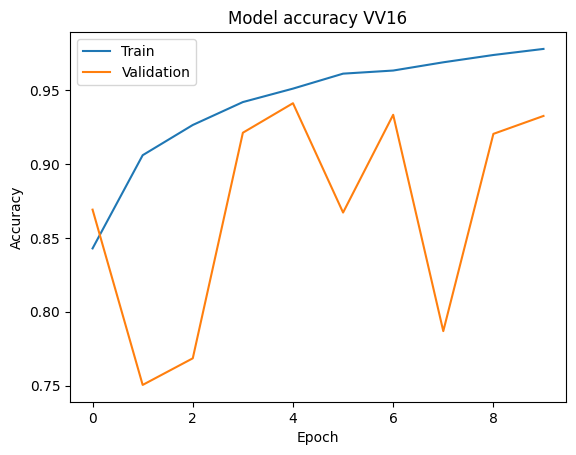

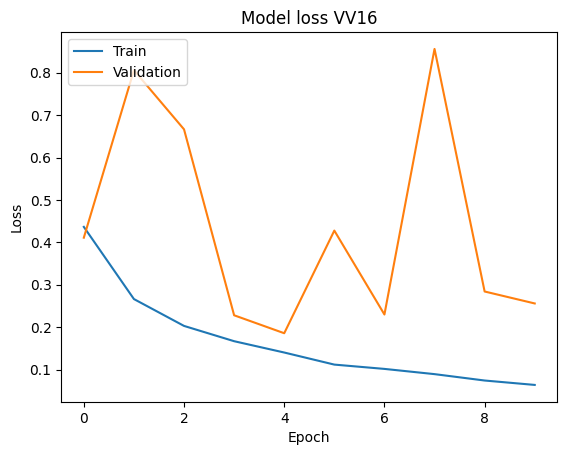

In [39]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy VV16')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss VV16')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [40]:
test_labels = test_datagen.classes
predictions = cnn_model.predict(test_datagen)
predicted_classes = np.argmax(predictions, axis=1)


160/160 ━━━━━━━━━━━━━━━━━━━━ 18s 107ms/step


In [41]:
report = classification_report(test_labels, predicted_classes, target_names=list(test_datagen.class_indices.keys()))
print(report)

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       638
           1       0.96      0.87      0.92       638
           2       0.96      0.98      0.97       638
           3       0.91      0.99      0.95       638

    accuracy                           0.95      2552
   macro avg       0.95      0.95      0.95      2552
weighted avg       0.95      0.95      0.95      2552



In [43]:
model_metrics = {}

def save_metrics_from_cm(conf_matrix, model_name):
    true_positives = np.diag(conf_matrix)
    actual_per_class = conf_matrix.sum(axis=1)
    predicted_per_class = conf_matrix.sum(axis=0)

    precision_per_class = np.divide(
        true_positives, predicted_per_class,
        out=np.zeros_like(true_positives, dtype=float),
        where=predicted_per_class != 0
    )

    recall_per_class = np.divide(
        true_positives, actual_per_class,
        out=np.zeros_like(true_positives, dtype=float),
        where=actual_per_class != 0
    )

    f1_per_class = np.divide(
        2 * precision_per_class * recall_per_class,
        precision_per_class + recall_per_class,
        out=np.zeros_like(precision_per_class),
        where=(precision_per_class + recall_per_class) != 0
    )

    weights = actual_per_class / actual_per_class.sum()

    model_metrics[model_name] = {
        "Accuracy": true_positives.sum() / conf_matrix.sum(),
        "Precision": np.sum(precision_per_class * weights),
        "Recall": np.sum(recall_per_class * weights),
        "F1 Score": np.sum(f1_per_class * weights)
    }

In [45]:
conf_matrix = confusion_matrix(test_labels, predicted_classes)
save_metrics_from_cm(conf_matrix, "VGG16")

Text(95.72222222222221, 0.5, 'True Label')

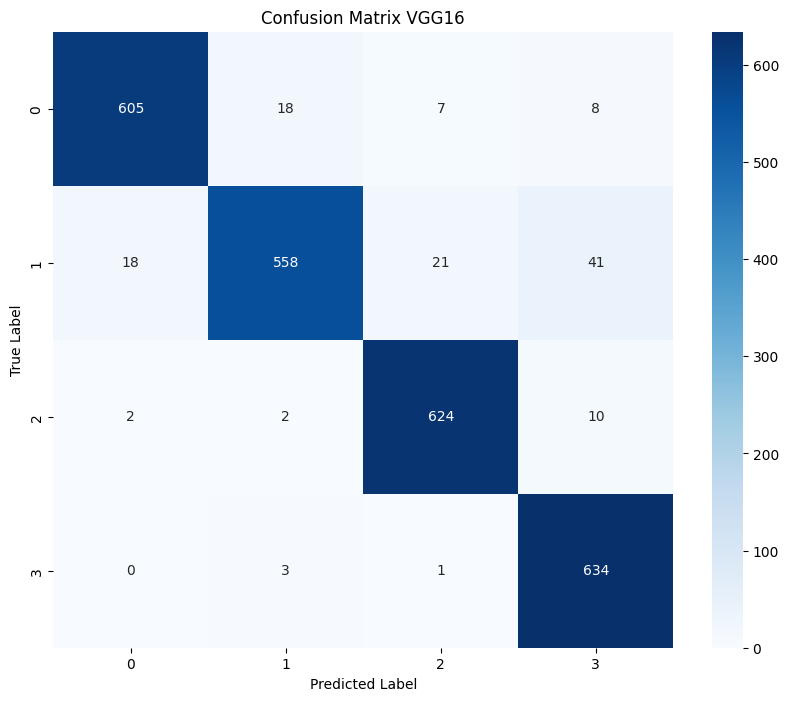

In [46]:
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix,annot=True, fmt="d", cmap="Blues", xticklabels=list(test_datagen.class_indices.keys()), yticklabels=list(test_datagen.class_indices.keys()))
plt.title('Confusion Matrix VGG16')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

In [47]:
# Define a function to create a VGG19-based model with added attention and custom layers
def create_vgg19_model(input_shape):

    # Define the input shape for the model
    inputs = Input(shape=input_shape)

    # Load the VGG19 base model with pre-trained weights (ImageNet)
    # Exclude the top layer (include_top=False) to add custom layers

    base_model = VGG19(weights='imagenet', include_top=False, input_tensor=inputs)

    #Freeze all layers in the base model to keep the weight from pre trained model during training

    for layer in base_model.layers:
        layer.trainable = False

    #Extract the output of the base model

    x = base_model.output

    #Define dimensions for reshaping

    height, width, channels = 7, 7, 512 #output dimensions from VGG16

    #Reshape output for multihead attention layer\

    x = Reshape((height * width, channels))(x)

    #Apply multi head attendtion layer to capture feature interactions

    attention_output = MultiHeadAttention(num_heads=8, key_dim=channels)(x, x)

    #Reshape back to spatial dimention

    attention_output = Reshape((height, width, channels))(attention_output)

     # Add Gaussian Noise to introduce slight randomness and enhance generalization

    x = GaussianNoise(0.25)(attention_output)

    #Global average pooling to reduce spacial dimension and keep essential features

    x = GlobalAveragePooling2D()(x)

    #Fully connected layer with RELU activation

    x = Dense(512 , activation='relu')(x)
    x = BatchNormalization()(x)  # Normalize activations to improve stability
    x = GaussianNoise(0.25)(x)   # Add Gaussian noise again for regularization
    x = Dropout(0.25)(x)         # Dropout to prevent overfitting

    #Output layer with softmax activation for multi class classifcation

    outputs = Dense(4, activation='softmax')(x)

    #Create the model

    model = Model(inputs=inputs, outputs=outputs)

    return model



In [48]:
#Set input shape for the model

input_shape = (224, 224, 3)

# Instantiate the model using the create_vgg19_model function

cnn_model = create_vgg19_model(input_shape)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [49]:
#Compile the model
cnn_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [50]:
#train the model
history = cnn_model.fit(
    train_datagen,
    validation_data=val_datagen,
    epochs=20,
    callbacks=[early_stopping],
    verbose=1)

Epoch 1/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 208s 158ms/step - accuracy: 0.8337 - loss: 0.4556 - val_accuracy: 0.7249 - val_loss: 0.8764
Epoch 2/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 199s 156ms/step - accuracy: 0.8934 - loss: 0.2981 - val_accuracy: 0.8025 - val_loss: 0.6082
Epoch 3/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 199s 156ms/step - accuracy: 0.9225 - loss: 0.2185 - val_accuracy: 0.6477 - val_loss: 2.1373
Epoch 4/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 199s 156ms/step - accuracy: 0.9356 - loss: 0.1830 - val_accuracy: 0.7520 - val_loss: 0.7423
Epoch 5/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 199s 156ms/step - accuracy: 0.9432 - loss: 0.1583 - val_accuracy: 0.9118 - val_loss: 0.2551


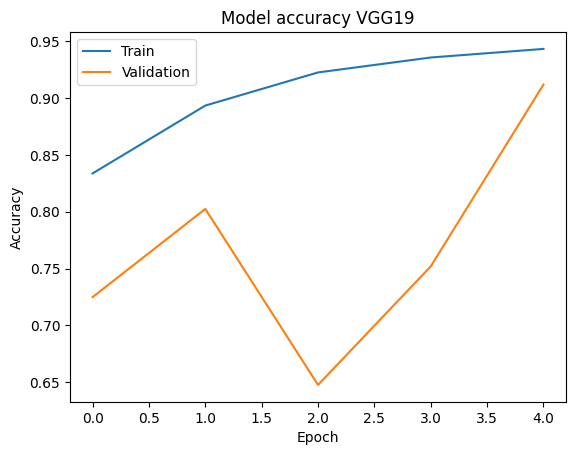

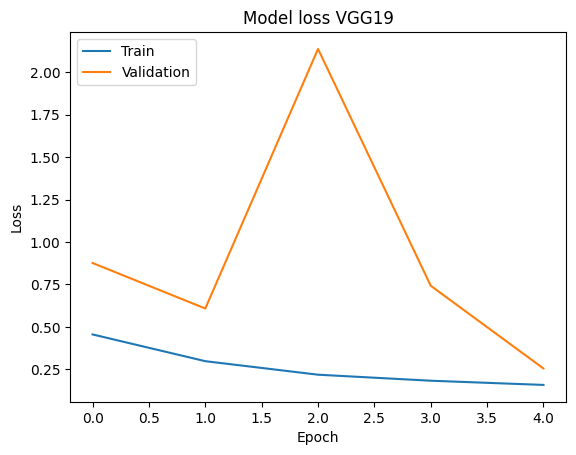

In [51]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy VGG19')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss VGG19')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [52]:
test_labels = test_datagen.classes
predictions = cnn_model.predict(test_datagen)
predicted_classes = np.argmax(predictions, axis=1)

160/160 ━━━━━━━━━━━━━━━━━━━━ 22s 134ms/step


In [53]:
report = classification_report(test_labels, predicted_classes, target_names=list(test_datagen.class_indices.keys()))
print(report)

              precision    recall  f1-score   support

           0       0.98      0.62      0.76       638
           1       0.91      0.37      0.53       638
           2       0.51      0.99      0.67       638
           3       0.89      0.89      0.89       638

    accuracy                           0.72      2552
   macro avg       0.82      0.72      0.71      2552
weighted avg       0.82      0.72      0.71      2552



In [54]:
conf_matrix = confusion_matrix(test_labels, predicted_classes)
save_metrics_from_cm(conf_matrix, "VGG19")

Text(95.72222222222221, 0.5, 'True Label')

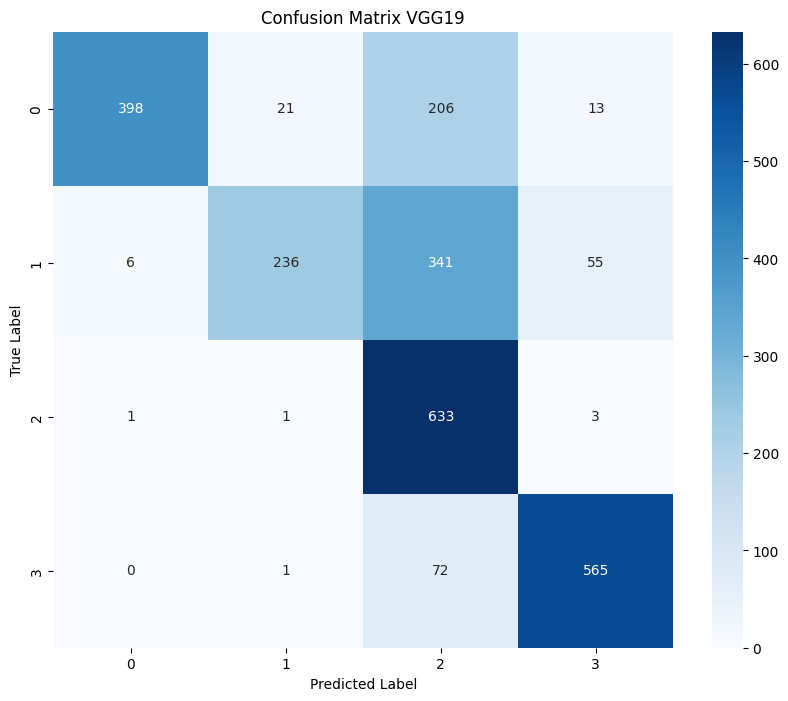

In [55]:
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix,annot=True, fmt="d", cmap="Blues", xticklabels=list(test_datagen.class_indices.keys()), yticklabels=list(test_datagen.class_indices.keys()))
plt.title('Confusion Matrix VGG19')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

In [56]:
#Base model is MobileNet
def create_mobilenet_model(input_shape):

    inputs = Input(shape=input_shape)

    base_model = MobileNet(weights='imagenet', input_tensor=inputs, include_top=False)

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output

    height, width, channels = 7, 7, 1024
    x = Reshape((height * width, channels))(x)

    attention_output = MultiHeadAttention(num_heads=8, key_dim=128)(x, x)

    attention_output = Reshape((height, width, channels))(attention_output)

    x = GaussianNoise(0.25)(attention_output)

    x = GlobalAveragePooling2D()(x)

    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = GaussianNoise(0.25)(x)
    x = Dropout(0.25)(x)

    outputs = Dense(4, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    return model


In [57]:
#Set input shape for the model

input_shape = (224, 224, 3)

# Instantiate the model using the create_vgg19_model function

cnn_model = create_mobilenet_model(input_shape)

/tmp/ipykernel_58/828426040.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(weights='imagenet', input_tensor=inputs, include_top=False)


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [59]:
cnn_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [60]:
history = cnn_model.fit(
    train_datagen,
    validation_data=val_datagen,
    epochs=20,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20


2026-08-10 20:11:46.318868: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-10 20:11:46.468149: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-10 20:11:46.604726: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1275/1276 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8498 - loss: 0.4148

2026-08-10 20:13:01.204488: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-10 20:13:01.341639: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1276/1276 ━━━━━━━━━━━━━━━━━━━━ 90s 56ms/step - accuracy: 0.8915 - loss: 0.3053 - val_accuracy: 0.9232 - val_loss: 0.2223
Epoch 2/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 58s 45ms/step - accuracy: 0.9463 - loss: 0.1556 - val_accuracy: 0.9404 - val_loss: 0.1819
Epoch 3/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 59s 46ms/step - accuracy: 0.9831 - loss: 0.0521 - val_accuracy: 0.9687 - val_loss: 0.0998
Epoch 6/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 59s 46ms/step - accuracy: 0.9878 - loss: 0.0365 - val_accuracy: 0.9706 - val_loss: 0.1178
Epoch 7/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 62s 48ms/step - accuracy: 0.9886 - loss: 0.0354 - val_accuracy: 0.9671 - val_loss: 0.1140
Epoch 8/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 60s 47ms/step - accuracy: 0.9880 - loss: 0.0345 - val_accuracy: 0.9722 - val_loss: 0.1113
Epoch 9/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 60s 47ms/step - accuracy: 0.9905 - loss: 0.0277 - val_accuracy: 0.9765 - val_loss: 0.1079
Epoch 10/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 59s 46ms/step - accuracy: 0.9923 - loss: 0.0

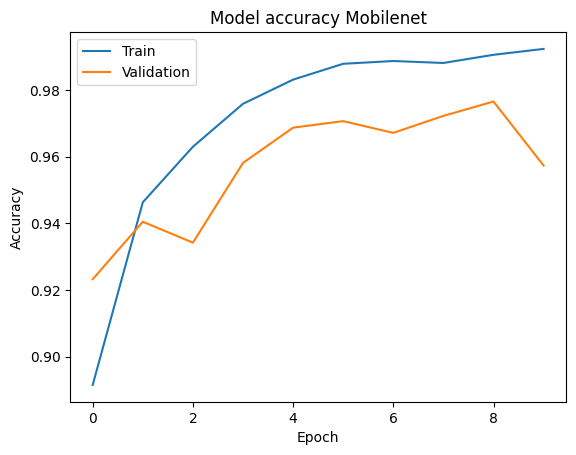

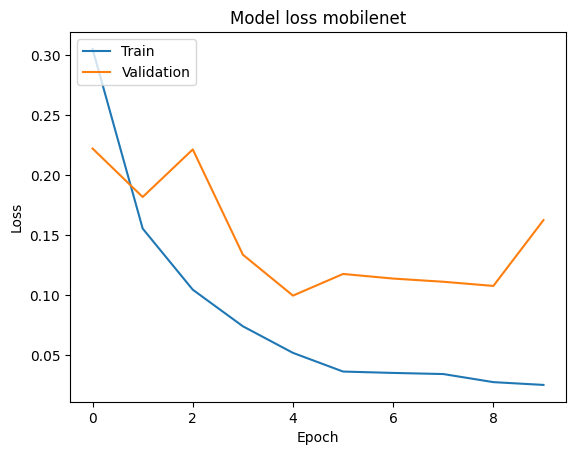

In [61]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy Mobilenet')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss mobilenet')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [62]:
test_labels = test_datagen.classes
predictions = cnn_model.predict(test_datagen)
predicted_classes = np.argmax(predictions, axis=1)

160/160 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step


In [63]:
report = classification_report(test_labels, predicted_classes, target_names=list(test_datagen.class_indices.keys()))
print(report)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       638
           1       0.94      0.95      0.94       638
           2       0.99      0.99      0.99       638
           3       0.99      0.96      0.97       638

    accuracy                           0.97      2552
   macro avg       0.97      0.97      0.97      2552
weighted avg       0.97      0.97      0.97      2552



In [65]:
conf_matrix = confusion_matrix(test_labels, predicted_classes)
save_metrics_from_cm(conf_matrix, "MobileNet")

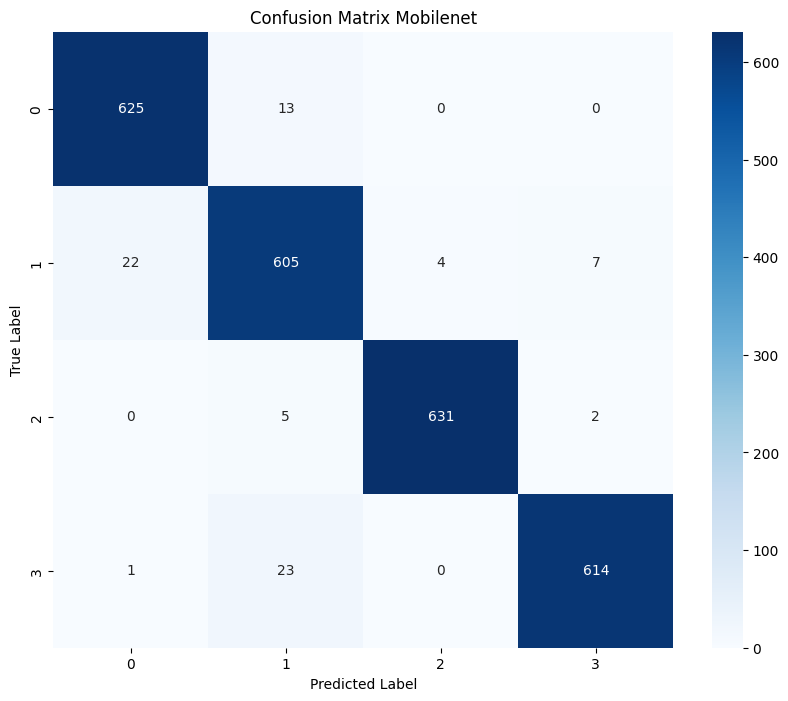

In [66]:
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=list(test_datagen.class_indices.keys()), yticklabels=list(test_datagen.class_indices.keys()))
plt.title('Confusion Matrix Mobilenet')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [67]:
#Basemodel is Xception
def create_xception_model(input_shape):

    inputs = Input(shape=input_shape)

    base_model = Xception(weights='imagenet', input_tensor=inputs, include_top=False)

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output

    height, width, channels = 7, 7, 2048
    x = Reshape((height * width, channels))(x)

    attention_output = MultiHeadAttention(num_heads=8, key_dim=128)(x, x)

    attention_output = Reshape((height, width, channels))(attention_output)

    x = GaussianNoise(0.25)(attention_output)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = GaussianNoise(0.25)(x)
    x = Dropout(0.25)(x)
    outputs = Dense(4, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    return model

In [68]:
#Set input shape for the model

input_shape = (224, 224, 3)

# Instantiate the model using the create_vgg19_model function

cnn_model = create_xception_model(input_shape)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [69]:
#Compile
cnn_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [70]:
history = cnn_model.fit(
    train_datagen,
    validation_data=val_datagen,
    epochs=20,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20


2026-08-10 20:23:48.257021: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-10 20:23:48.411298: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-10 20:23:49.875095: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-10 20:23:50.009073: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-10 20:23:51.057863: E external/local_xla/xla/stream_

1276/1276 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7947 - loss: 0.5764

2026-08-10 20:25:53.540992: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-10 20:25:53.681297: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-10 20:25:54.762236: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-10 20:25:54.895165: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-10 20:25:55.836234: E external/local_xla/xla/stream_

1276/1276 ━━━━━━━━━━━━━━━━━━━━ 143s 95ms/step - accuracy: 0.8424 - loss: 0.4425 - val_accuracy: 0.8860 - val_loss: 0.3581
Epoch 2/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 106s 83ms/step - accuracy: 0.9036 - loss: 0.2767 - val_accuracy: 0.8942 - val_loss: 0.3207
Epoch 3/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 106s 83ms/step - accuracy: 0.9245 - loss: 0.2132 - val_accuracy: 0.9126 - val_loss: 0.2593
Epoch 4/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 106s 83ms/step - accuracy: 0.9427 - loss: 0.1659 - val_accuracy: 0.9381 - val_loss: 0.1899
Epoch 5/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 106s 83ms/step - accuracy: 0.9550 - loss: 0.1227 - val_accuracy: 0.9416 - val_loss: 0.1657


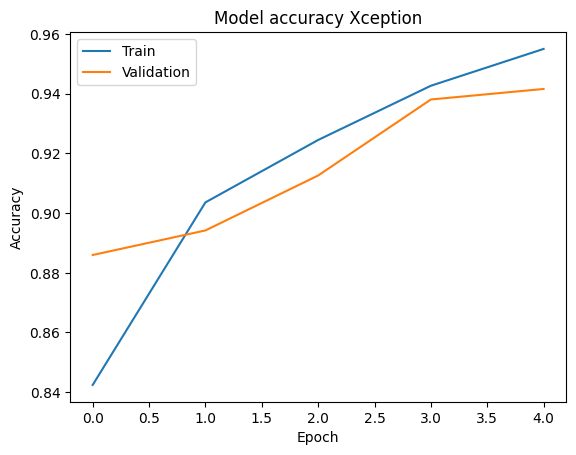

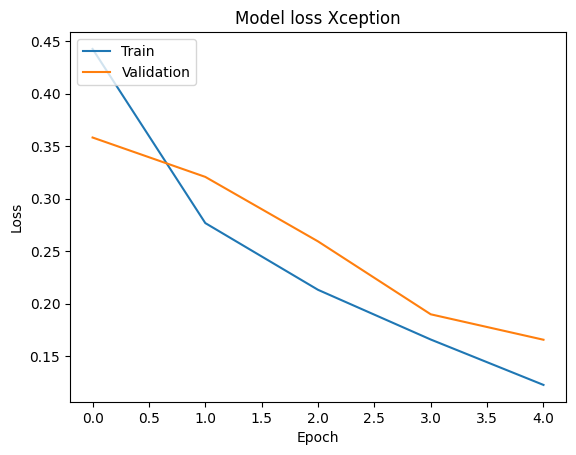

In [71]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy Xception')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss Xception')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [73]:
test_labels = test_datagen.classes
predictions = cnn_model.predict(test_datagen)
predicted_classes = np.argmax(predictions, axis=1)

160/160 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step


In [74]:
report = classification_report(test_labels, predicted_classes, target_names=list(test_datagen.class_indices.keys()))
print(report)

              precision    recall  f1-score   support

           0       0.96      0.86      0.91       638
           1       0.86      0.75      0.80       638
           2       0.94      0.98      0.96       638
           3       0.82      0.98      0.90       638

    accuracy                           0.89      2552
   macro avg       0.90      0.89      0.89      2552
weighted avg       0.90      0.89      0.89      2552



In [75]:
conf_matrix = confusion_matrix(test_labels, predicted_classes)
save_metrics_from_cm(conf_matrix, "Xception")

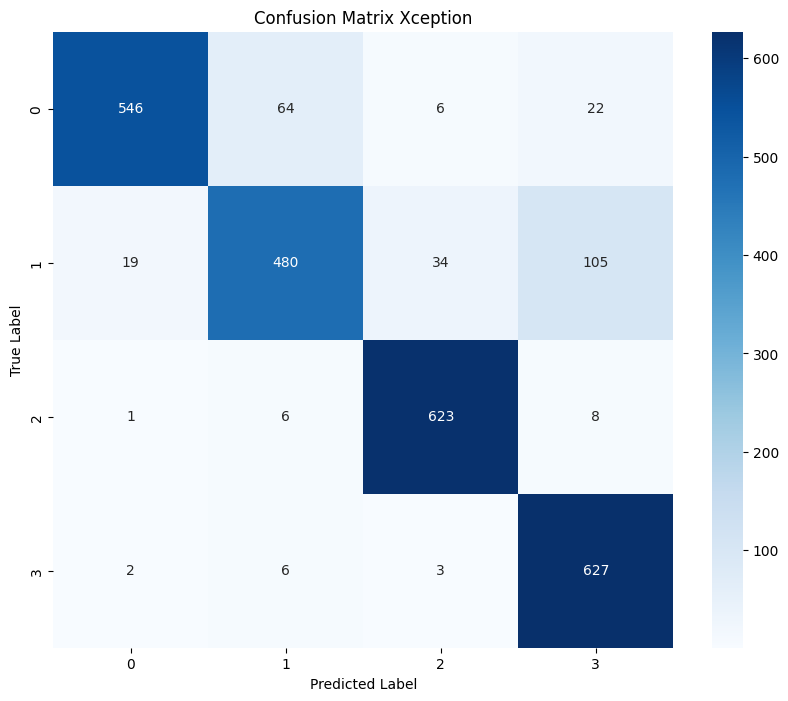

In [76]:
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=list(test_datagen.class_indices.keys()), yticklabels=list(test_datagen.class_indices.keys()))
plt.title('Confusion Matrix Xception')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [77]:
def create_inception_model(input_shape):

    inputs = Input(shape=input_shape)

    base_model = InceptionV3(weights='imagenet', input_tensor=inputs, include_top=False)

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output

    height, width, channels = 5, 5, 2048
    x = Reshape((height * width, channels))(x)

    attention_output = MultiHeadAttention(num_heads=8, key_dim=128)(x, x)

    attention_output = Reshape((height, width, channels))(attention_output)

    x = GaussianNoise(0.25)(attention_output)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = GaussianNoise(0.25)(x)
    x = Dropout(0.25)(x)
    outputs = Dense(4, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    return model


In [78]:
#Set input shape for the model

input_shape = (224, 224, 3)

# Instantiate the model using the create_vgg19_model function

cnn_model = create_inception_model(input_shape)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [79]:
#Compile
cnn_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [80]:
#Train the model
history = cnn_model.fit(
    train_datagen,
    validation_data=val_datagen,
    epochs=20,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 100s 63ms/step - accuracy: 0.8371 - loss: 0.4566 - val_accuracy: 0.8570 - val_loss: 0.4374
Epoch 2/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 67s 53ms/step - accuracy: 0.9122 - loss: 0.2482 - val_accuracy: 0.8460 - val_loss: 0.4257
Epoch 3/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 67s 52ms/step - accuracy: 0.9400 - loss: 0.1726 - val_accuracy: 0.9381 - val_loss: 0.2019
Epoch 4/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 70s 55ms/step - accuracy: 0.9536 - loss: 0.1331 - val_accuracy: 0.9436 - val_loss: 0.1687
Epoch 5/20
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 67s 52ms/step - accuracy: 0.9629 - loss: 0.1087 - val_accuracy: 0.9522 - val_loss: 0.1813


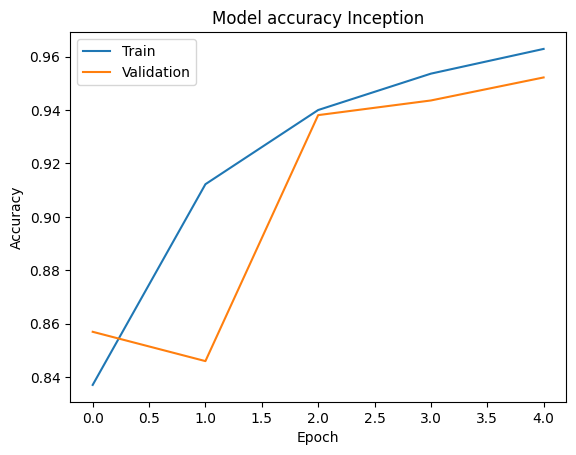

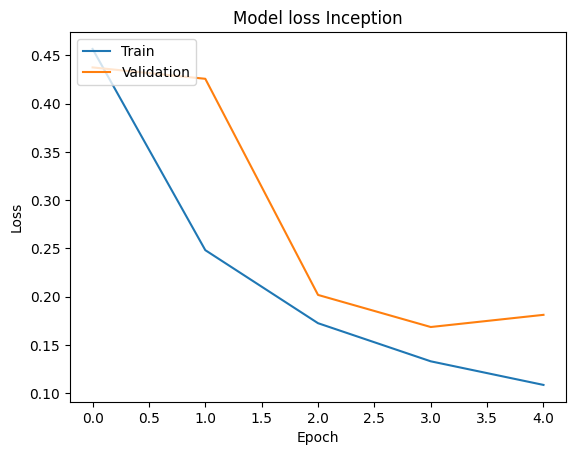

In [81]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy Inception')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss Inception')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [82]:
test_labels = test_datagen.classes
predictions = cnn_model.predict(test_datagen)
predicted_classes = np.argmax(predictions, axis=1)

160/160 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step


In [83]:
report = classification_report(test_labels, predicted_classes, target_names=list(test_datagen.class_indices.keys()))
print(report)

              precision    recall  f1-score   support

           0       0.99      0.74      0.85       638
           1       0.81      0.73      0.77       638
           2       0.91      0.98      0.94       638
           3       0.78      0.99      0.87       638

    accuracy                           0.86      2552
   macro avg       0.87      0.86      0.86      2552
weighted avg       0.87      0.86      0.86      2552



In [85]:
conf_matrix = confusion_matrix(test_labels, predicted_classes)
save_metrics_from_cm(conf_matrix, "InceptionV3")

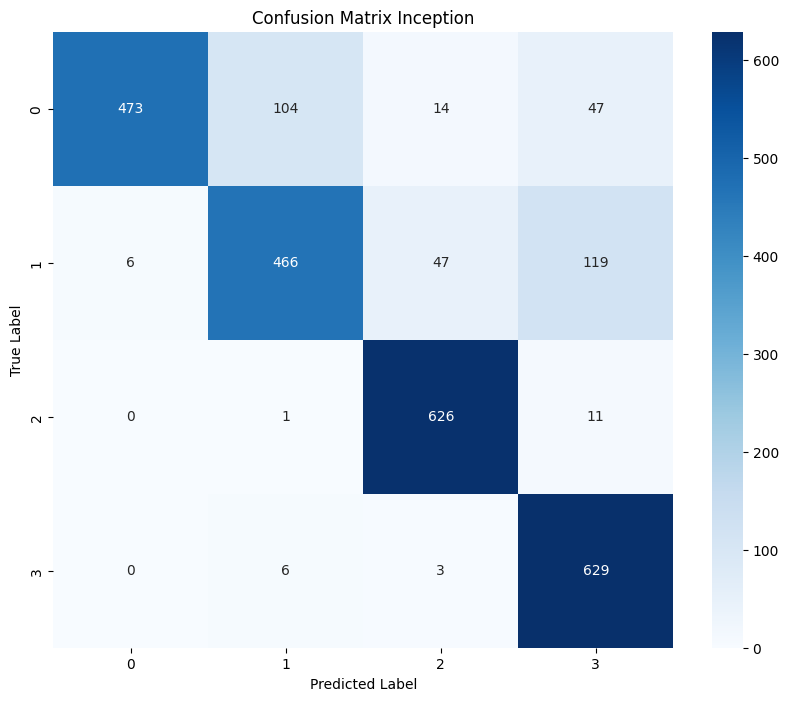

In [86]:
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=list(test_datagen.class_indices.keys()), yticklabels=list(test_datagen.class_indices.keys()))
plt.title('Confusion Matrix Inception')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

,Accuracy,Precision,Recall,F1 Score
VGG16,0.948668,0.949716,0.948668,0.948225
VGG19,0.717868,0.821967,0.717868,0.711548
MobileNet,0.969828,0.970073,0.969828,0.969891
Xception,0.891850,0.895712,0.891850,0.890182
InceptionV3,0.859718,0.870686,0.859718,0.856988


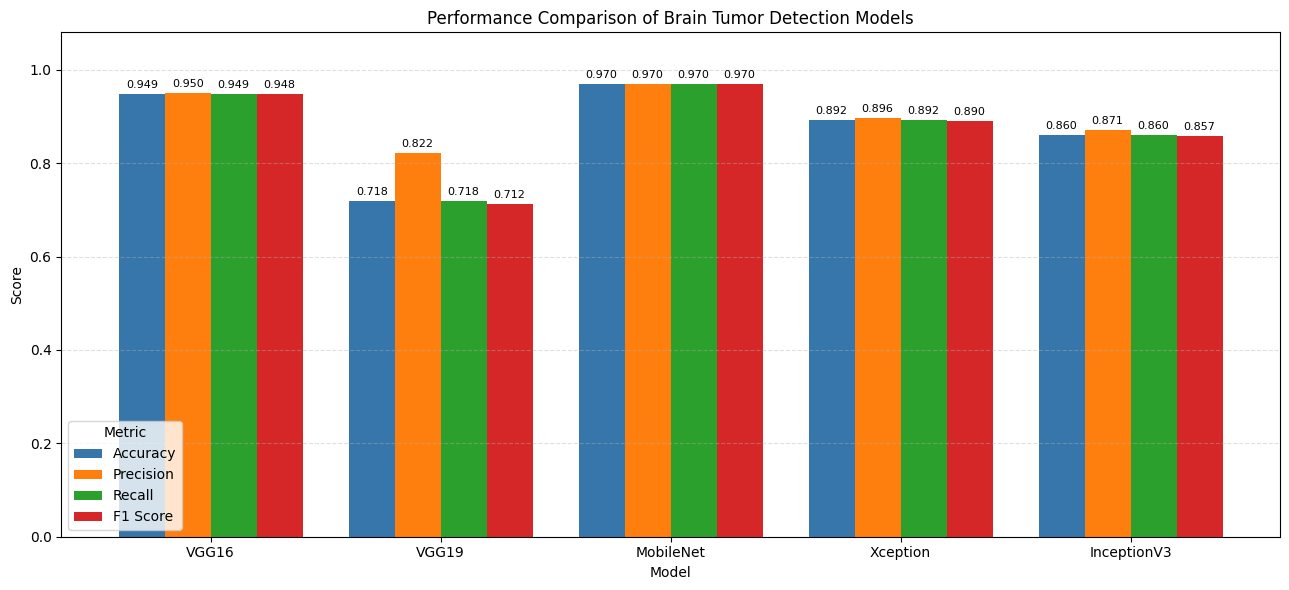

In [87]:
metrics_df = pd.DataFrame(model_metrics).T
display(metrics_df)

ax = metrics_df.plot(
    kind="bar",
    figsize=(13, 6),
    color=["#3776AB", "#FF7F0E", "#2CA02C", "#D62728"],
    width=0.8
)

plt.title("Performance Comparison of Brain Tumor Detection Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.08)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)

plt.tight_layout()
plt.show()